## **Librerias:**

In [1]:
import pandas as pd
from scipy.stats import shapiro
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

### **Funciones:**

In [2]:
def prueba_normalidad_shap (df, variable):
    stat, p = shapiro(df[variable].dropna())
    print('Estadístico=%.3f, p=%.3f' % (stat, p))

    if p > 0.05:
        print('No se rechaza H0 → parece normal')
    else:
        print('Se rechaza H0 → no es normal')

In [3]:
def analizar_distribucion(df, columna, color="#4682B4"):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                        gridspec_kw={"height_ratios": (.15, .85)},
                                        figsize=(8, 6))
    
    sns.boxplot(x=df[columna], ax=ax_box, color=color, fliersize=5)
    ax_box.set(xlabel='') 
    ax_box.set_title(f'Distribución de la Variable: {columna}', fontsize=14)
    
    sns.histplot(df[columna], ax=ax_hist, kde=True, color=color, bins=30)
    ax_hist.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [4]:
def Resumen_Faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    # Mostrar solo columnas con NA
    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

In [5]:
def resumen_var_cat(df):
    conteo = df.value_counts(dropna=False)
    porcentaje = df.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(10)  # opcional
    
    # 🎨 estilo bonito
    styled = resumen.style \
        .format({'porcentaje': '{:.2f}%'})
    
    display(styled)

## **Cargar datos:**

In [6]:
df = pd.read_excel("df_afro_clean.xlsx")

In [7]:
pd.set_option("display.max_columns", None)
df.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,NaN,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,NaN,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,NaN,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,NaN,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


## **Observando los datos:**

### **Tipos de Datos:**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GRUPO                         1357 non-null   object 
 1   Departamento_Tamizaje         1357 non-null   object 
 2   Municipio_Tamizaje            1357 non-null   object 
 3   Edad                          1357 non-null   int64  
 4   Genero                        1357 non-null   object 
 5   Escolaridad                   1357 non-null   object 
 6   Regimen_Salud                 1357 non-null   object 
 7   Ocupacion                     1357 non-null   object 
 8   Medicacion_Diabetes           1357 non-null   object 
 9   Diabetes_Embarazo             1357 non-null   object 
 10  Hipertension                  1357 non-null   object 
 11  Medicacion_Hipertension       1357 non-null   object 
 12  Colesterol_Alto               1357 non-null   object 
 13  Med

In [9]:
df['Regimen_Salud'].unique()

array(['Subsidiado', 'No tiene', 'Contributivo', 'Especial', 'N.d.'],
      dtype=object)

In [10]:
columnas_categoricas = ['Presion_Sistolica\t> 130', 'Presion_Diastolica > 90']

df[columnas_categoricas] = df[columnas_categoricas].astype('category')

In [11]:
num_registros = len(df)
num_variables = len(df.columns)
num_numericas = df.select_dtypes(include='number').shape[1]
num_categoricas = df.select_dtypes(include='object').shape[1]

print(f"Tenemos un conjunto de datos compuesto por {num_registros} registros y {num_variables} variables, de las cuales {num_numericas} son numéricas y {num_categoricas} son categóricas.")

Tenemos un conjunto de datos compuesto por 1357 registros y 62 variables, de las cuales 10 son numéricas y 50 son categóricas.


### **Nombres de las variables Numéricas:**

In [12]:
df.select_dtypes(include = "number").columns

Index(['Edad', 'Cantidad_Fumador', 'Peso', 'Talla', 'IMC', 'Creatinina',
       'TFG_CDK_EPI', 'TFG_Edad', 'Presion_Sistolica', 'Presion_Diastolica'],
      dtype='object')

### **Nombres de las Variables Categóricas:**

In [13]:
df.select_dtypes(include = "object").columns

Index(['GRUPO', 'Departamento_Tamizaje', 'Municipio_Tamizaje', 'Genero',
       'Escolaridad', 'Regimen_Salud', 'Ocupacion', 'Medicacion_Diabetes',
       'Diabetes_Embarazo', 'Hipertension', 'Medicacion_Hipertension',
       'Colesterol_Alto', 'Medicacion_Colesterol', 'Insuficiencia_Renal',
       'Dialisis', 'Proteina_Sangre_Orina', 'Alergias', 'Nombre_Alergenos',
       'Consumo_Tabaco', 'Fumador_100Cigs', 'Consumo_Alcohol',
       'Frecuencia_Alcohol', 'Embriaguez', 'Consumo_Drogas', 'Trabajo_Cultivo',
       'Uso_Insecticidas', 'Uso_Fungicidas', 'Uso_Fertilizantes',
       'Proteccion_Pesticidas', 'Metodo_Aplicacion_Pesticidas',
       'Sintomas_Trabajo', 'Consumo_Agua_Trabajo', 'Ultima_Consulta_Medica',
       'Dificultad_Atencion_Medica', 'Ultimo_Profesional_Salud',
       'Medico_Cabecera', 'Grupo_Sanguineo', 'Transfusion_Sanguinea',
       'Antecedentes_Familiares', 'Familiar_Insuficiencia_Renal',
       'Familiar_Dialisis', 'Sintomas_Recientes', 'Uso_AINES',
       'Uso_Medic

### **Notas:**

Se evidencia la ausencia de una variable que funcione como identificador único del paciente, lo cual dificulta diferenciar correctamente los registros y garantizar que el formulario no haya sido aplicado más de una vez a la misma persona.

## **Duplicados:**

In [14]:
print("En este dataset podemos encontrar {} resgistros duplicados".format(df.duplicated().sum()))

En este dataset podemos encontrar 1 resgistros duplicados


In [15]:
df_duplicados = df[df.duplicated(keep = False)]
df_duplicados

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
407,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 5 litros,Mayor a 6 meses,Difícil,Medico General,No,O+,No,Enfermedad Cardiaca,No,No,Ninguno,No,No,Suministro municipal,85,1.8,26.234568,Negativo,NaN,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto
1023,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 5 litros,Mayor a 6 meses,Difícil,Medico General,No,O+,No,Enfermedad Cardiaca,No,No,Ninguno,No,No,Suministro municipal,85,1.8,26.234568,Negativo,NaN,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto


Ante la presencia de un registro duplicado, se procederá a conservar el que aparece en primer lugar y a eliminar aquel que se encuentra en una posición posterior, bajo el supuesto de que el primer registro corresponde a la captura original y los siguientes podrían derivarse de errores de digitación, reprocesamiento o redundancias en la recolección de la información.

In [16]:
df= df.drop_duplicates(keep='first')
print("Dentro del dataset aun quedan {} registros duplicados".format(df.duplicated().sum()))

Dentro del dataset aun quedan 0 registros duplicados


In [17]:
df[df.duplicated(keep=False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC


## **Valores Faltantes:**

A continuación, se procederá a analizar el porcentaje de valores faltantes en cada una de las variables del conjunto de datos.

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


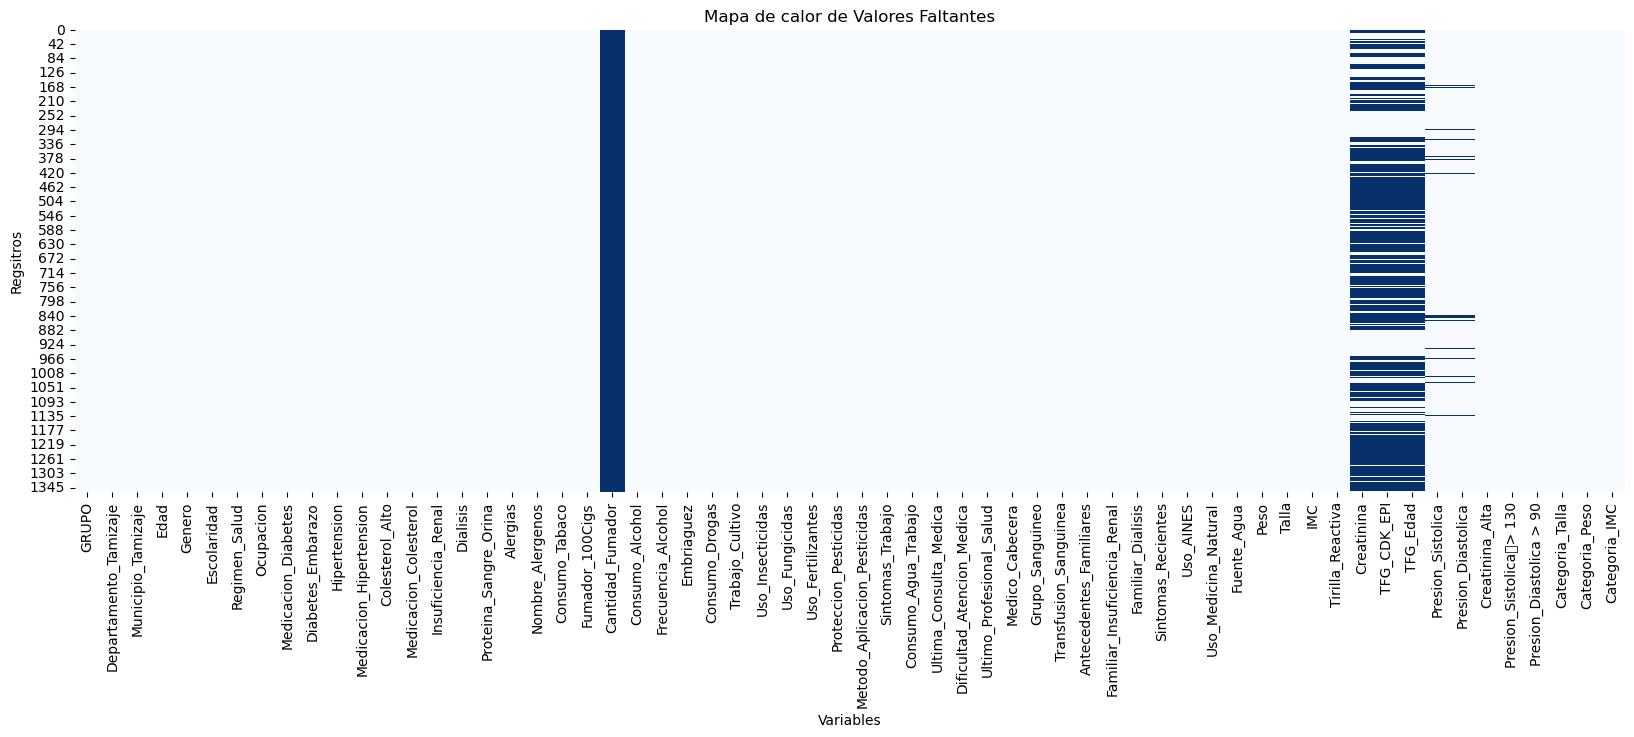

In [18]:
plt.figure(figsize = (20,6))
sns.heatmap(df.isnull(),cbar=False,cmap= "Blues")
plt.title("Mapa de calor de Valores Faltantes")
plt.xlabel("Variables")
plt.ylabel("Regsitros")
plt.show()

In [19]:
Resumen_Faltantes(df)

,Valores faltantes,Porcentaje (%)
Cantidad_Fumador,1356,100.000000
Creatinina,886,65.339233
TFG_CDK_EPI,886,65.339233
TFG_Edad,886,65.339233
Presion_Sistolica,47,3.466077
Presion_Diastolica,47,3.466077


La variable ``Cantidad_Fumador``, al encontrarse completamente vacía, será eliminada de la base de datos.

In [20]:
df = df.drop(columns=['Cantidad_Fumador'])
df.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,NaN,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,NaN,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,NaN,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


 Por otro lado, las variables ``Presion_Sistolica`` y ``Presion_Diastolica`` presentan un 3.46% de valores faltantes (aproximadamente 47 registros), por lo que podrían imputarse mediante medidas de tendencia central como la media o la mediana; no obstante, esta decisión debe evaluarse previamente.

En cuanto a las variables ``Creatinina``, ``TFG_CDK_EPI`` y ``TFG_Edad``, la situación es más compleja, ya que presentan un 65.34% de valores faltantes (alrededor de 886 registros). Dada esta alta proporción, sería necesario considerar métodos de imputación más avanzados, como modelos predictivos. Sin embargo, es fundamental evaluar cuidadosamente que dichos métodos no alteren de manera significativa la distribución original de los datos ni introduzcan sesgos en el análisis.

In [21]:
# A. Ver solo los registros donde Creatinina es NaN (Nulo)
df_nulos_creatinina = df[df['Creatinina'].isnull()]

# B. Ver cuántos registros son en total (deberían ser 887, ya que tienes 470 no nulos de 1357)
print(f"Total de registros sin Creatinina: {len(df_nulos_creatinina)}")

Total de registros sin Creatinina: 886


## **Análisis Variables Numéricas para Imputar:**

### ``Presion_Sistolica``, ``Presion_Diastolica``, `Creatinina`

#### **Distribución con Valores Faltantes:**

In [22]:
df[['TFG_Edad','TFG_CDK_EPI','Creatinina']].describe()

,TFG_Edad,TFG_CDK_EPI,Creatinina
count,470.000000,470.000000,470.000000
mean,82.536170,81.542596,1.156787
std,17.417419,31.470822,0.388140
min,33.000000,22.140000,0.600000
25%,71.250000,54.545000,0.806750
50%,82.000000,78.830000,1.000000
75%,94.000000,105.972500,1.479500
max,116.000000,168.190000,2.500000


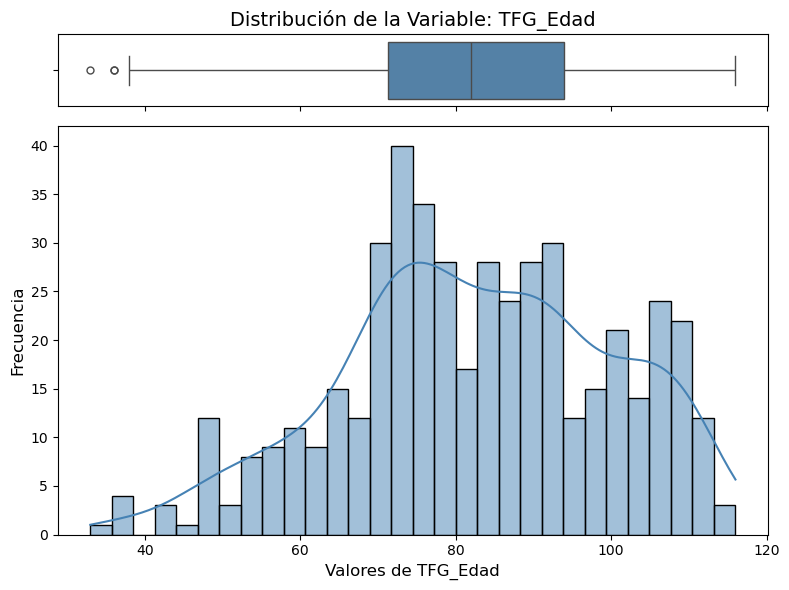

In [23]:
analizar_distribucion(df,"TFG_Edad")

In [24]:
prueba_normalidad_shap(df,"TFG_Edad")

Estadístico=0.982, p=0.000
Se rechaza H0 → no es normal


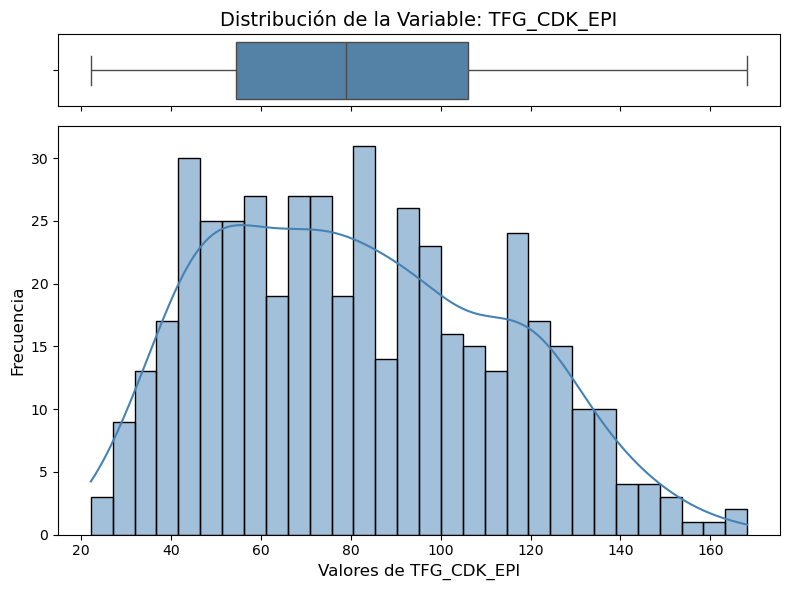

In [25]:
analizar_distribucion(df,"TFG_CDK_EPI")

In [26]:
prueba_normalidad_shap(df,"TFG_CDK_EPI")

Estadístico=0.974, p=0.000
Se rechaza H0 → no es normal


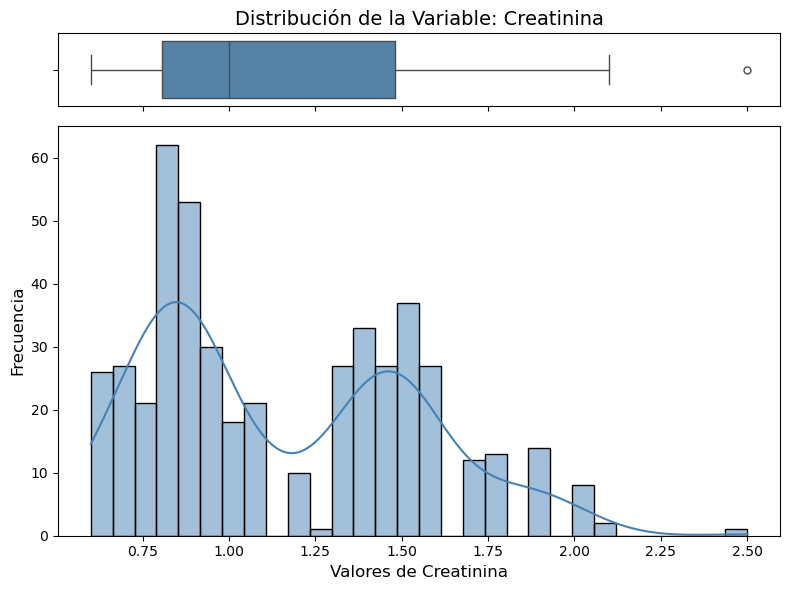

In [27]:
analizar_distribucion(df,"Creatinina")

In [28]:
prueba_normalidad_shap(df,"Creatinina")

Estadístico=0.932, p=0.000
Se rechaza H0 → no es normal


Tenemos que las variables no siguen una distribución normal 

In [29]:
df_original = df.copy()

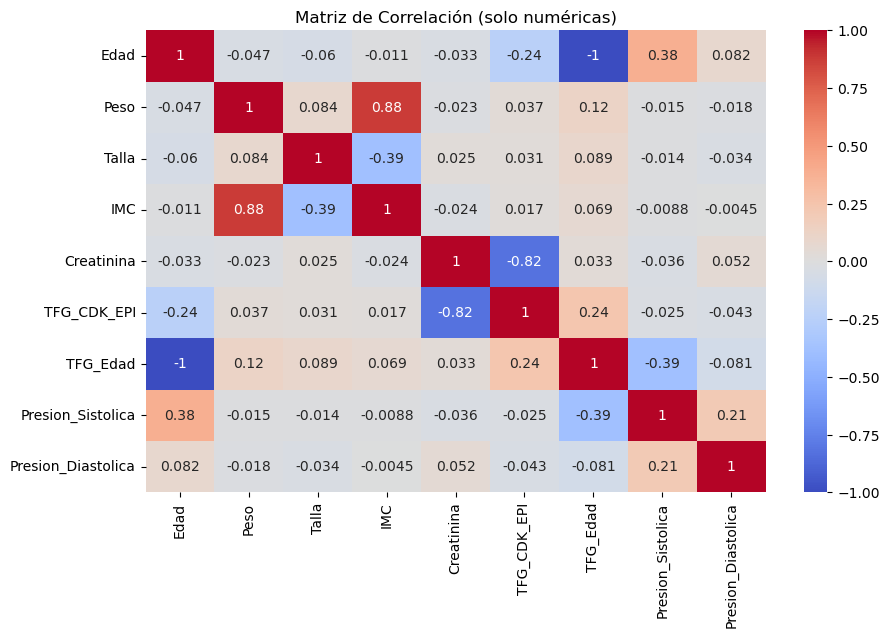

In [30]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include="number")

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

# Visualizar con un heatmap
plt.figure(figsize = (10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación (solo numéricas)')
plt.show()

In [31]:
correlation_matrix


,Edad,Peso,Talla,IMC,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica
Edad,1.000000,-0.046569,-0.060008,-0.011323,-0.033114,-0.241509,-1.000000,0.383177,0.081777
Peso,-0.046569,1.000000,0.083512,0.879166,-0.023000,0.037067,0.123570,-0.015334,-0.018196
Talla,-0.060008,0.083512,1.000000,-0.389961,0.025483,0.030854,0.089354,-0.014198,-0.034454
IMC,-0.011323,0.879166,-0.389961,1.000000,-0.024319,0.017094,0.069150,-0.008799,-0.004463
Creatinina,-0.033114,-0.023000,0.025483,-0.024319,1.000000,-0.820690,0.033114,-0.035735,0.052361
TFG_CDK_EPI,-0.241509,0.037067,0.030854,0.017094,-0.820690,1.000000,0.241509,-0.024684,-0.043195
TFG_Edad,-1.000000,0.123570,0.089354,0.069150,0.033114,0.241509,1.000000,-0.387773,-0.081449
Presion_Sistolica,0.383177,-0.015334,-0.014198,-0.008799,-0.035735,-0.024684,-0.387773,1.000000,0.207918
Presion_Diastolica,0.081777,-0.018196,-0.034454,-0.004463,0.052361,-0.043195,-0.081449,0.207918,1.000000


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer  # necesario
from sklearn.impute import IterativeImputer
import pandas as pd

# Seleccionar columnas a imputar
cols = [ 'Creatinina', 'TFG_CDK_EPI', 'TFG_Edad']

# Crear copia (MUY IMPORTANTE)
df_imputed = df.copy()

# Definir imputador
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

df_imputed[cols] = imputer.fit_transform(df_imputed[cols])

In [33]:
Resumen_Faltantes(df_imputed)

,Valores faltantes,Porcentaje (%)
Presion_Sistolica,47,3.466077
Presion_Diastolica,47,3.466077


Text(0.5, 1.0, 'Top 10 variables que más influyen en la Creatinina')

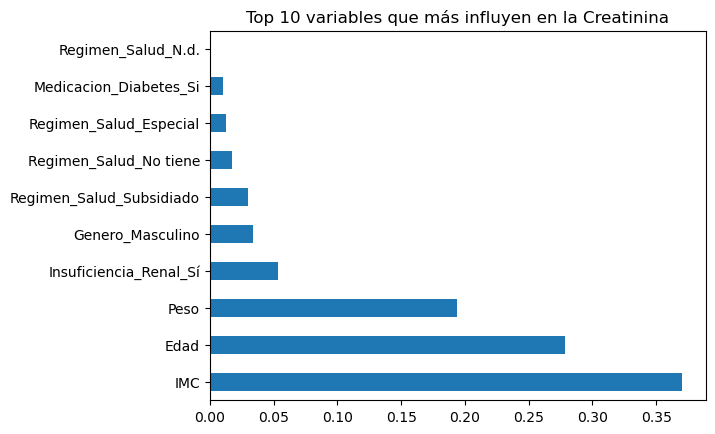

In [61]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. Selección inicial
variables_clinicas = ['Creatinina', 'IMC', 'Genero', 'Edad', 'Medicacion_Diabetes', 
                      'Insuficiencia_Renal', 'Peso', 'Regimen_Salud']
df_subset = df[variables_clinicas].copy()

# 2. Transformación a dummies (Aquí es donde el número de columnas cambia, p. ej. de 8 a 11)
df_subset_dummies = pd.get_dummies(
    df_subset, 
    columns=['Genero', 'Medicacion_Diabetes', 'Insuficiencia_Renal', 'Regimen_Salud'], 
    drop_first=True, 
    dtype=int 
)

from sklearn.ensemble import RandomForestRegressor

# Filtramos solo filas completas para la prueba
df_test = df_subset_dummies.dropna()
X = df_test.drop('Creatinina', axis=1)
y = df_test['Creatinina']

model = RandomForestRegressor().fit(X, y)

# Ver importancia
importancias = pd.Series(model.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title("Top 10 variables que más influyen en la Creatinina")


In [ ]:

# 3. Configuración del imputador
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10),
    max_iter=10, 
    random_state=42
)

# 4. IMPUTACIÓN (Ajuste clave aquí)
# El resultado es un array de numpy
datos_array = mice_imputer.fit_transform(df_subset_dummies)

# Creamos el DataFrame usando las columnas de 'df_subset_dummies' (las reales)
df_imputado = pd.DataFrame(
    datos_array, 
    columns=df_subset_dummies.columns  # <--- CAMBIO CLAVE
)


df['Creatinina'] = df_imputado['Creatinina'].values

In [ ]:
variable = 'Creatinina'

sns.kdeplot(df_original[variable].dropna(), label='Original')
sns.kdeplot(df_imputado[variable], label='Imputado')
plt.legend()
plt.show()

In [ ]:
df["Creatinina"].describe()

In [ ]:
df_imputado["Creatinina"].describe()

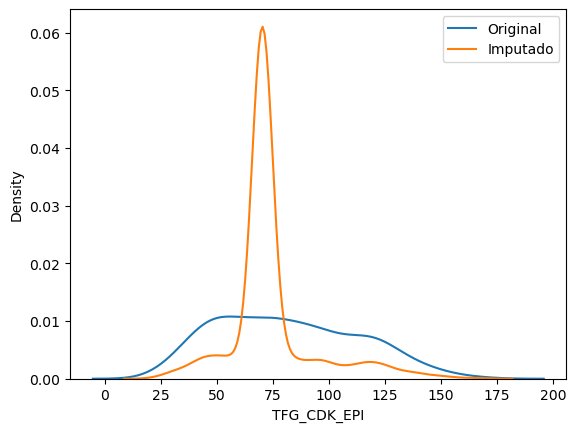

In [315]:
variable = 'TFG_CDK_EPI'

sns.kdeplot(df_original[variable].dropna(), label='Original')
sns.kdeplot(df_imputed[variable], label='Imputado')
plt.legend()
plt.show()

In [316]:
df_original["TFG_CDK_EPI"].describe()

count    470.000000
mean      81.542596
std       31.470822
min       22.140000
25%       54.545000
50%       78.830000
75%      105.972500
max      168.190000
Name: TFG_CDK_EPI, dtype: float64

In [317]:
df_imputed["TFG_CDK_EPI"].describe()

count    1356.000000
mean       74.163251
std        19.279916
min        22.140000
25%        70.248700
50%        70.248700
75%        70.248700
max       168.190000
Name: TFG_CDK_EPI, dtype: float64

In [55]:
import numpy as np

df_imputed_2 = df.copy()

# 1. Tomar valores reales (sin NA)
valores = df['Creatinina'].dropna()

# 2. Contar cuántos faltan
n_faltantes = df['Creatinina'].isna().sum()

# 3. Rellenar con valores aleatorios de la distribución real
df_imputed_2.loc[df['Creatinina'].isna(), 'Creatinina'] = np.random.choice(
    valores, 
    size=n_faltantes
)

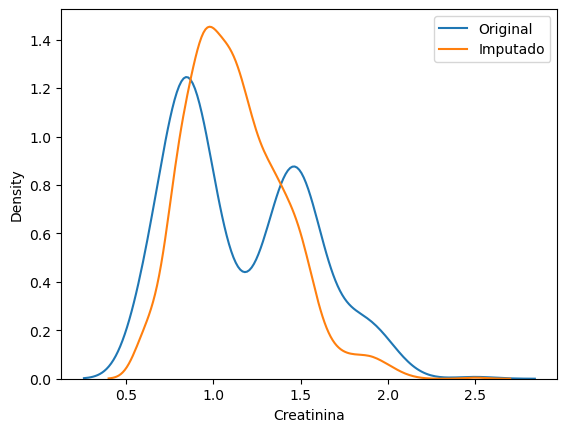

In [56]:
variable = 'Creatinina'

sns.kdeplot(df_original[variable].dropna(), label='Original')
sns.kdeplot(df_imputed_2[variable], label='Imputado')
plt.legend()
plt.show()

In [57]:
df["Creatinina"].describe()

count    1356.000000
mean        1.123849
std         0.280701
min         0.600000
25%         0.915750
50%         1.093271
75%         1.304006
max         2.500000
Name: Creatinina, dtype: float64

In [58]:
df_imputed_2["Creatinina"].describe()

count    1356.000000
mean        1.123849
std         0.280701
min         0.600000
25%         0.915750
50%         1.093271
75%         1.304006
max         2.500000
Name: Creatinina, dtype: float64

In [59]:
from scipy.stats import ks_2samp
variable = "Creatinina"
stat, p = ks_2samp(df_original[variable].dropna(), df_imputed_2[variable].dropna())
print(f"KS statistic: {stat:.3f}, p-value: {p:.3f}")

if(p > 0.05):
    print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
else:
    print("La distribución cambió significativamente")

KS statistic: 0.177, p-value: 0.000
La distribución cambió significativamente


In [323]:
prueba_normalidad_shap(df_original,"Creatinina")

Estadístico=0.932, p=0.000
Se rechaza H0 → no es normal


In [324]:
prueba_normalidad_shap(df_imputed_2,"Creatinina")

Estadístico=0.934, p=0.000
Se rechaza H0 → no es normal


## **Descriptive analysis**

### **Variables categóricas**

In [ ]:
mapeo = {
    'Subsidiado': 'Subsidiado', 
    'No tiene': 'No tiene',
    'Contributivo': 'Contributivo',
    'Especial': 'Contributivo',
    
}

df['Regimen_Salud'] = df['Regimen_Salud'].replace(mapeo)

print(df['Regimen_Salud'].value_counts())


Regimen_Salud
Subsidiado      907
Contributivo    359
No tiene         89
N.d.              1
Name: count, dtype: int64


In [326]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [327]:
def resumen_categoricas(df,col_names):
    for col in col_names:
        conteo = df[col].value_counts(dropna=False)
        porcentaje = df[col].value_counts(normalize=True, dropna=False) * 100

        resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
        })
        num_categorias = len(resumen)
        
        resumen = resumen.head(10)  

        styled = resumen.style \
        .set_caption(f"Distribución de {col} tiene {num_categorias} categorías") \
        .format({'porcentaje': '{:.2f}%'})

        display(styled)

In [328]:
resumen_categoricas(df,cat_cols)

,categorias,conteo,porcentaje
0,AFRODESCENDIENTE,1356,100.00%


,categorias,conteo,porcentaje
0,ATLANTICO,960,70.80%
1,BOLIVAR,395,29.13%
2,PALENQUE,1,0.07%


,categorias,conteo,porcentaje
0,BARRANQUILLA,572,42.18%
1,SAN JOSE DE SACO,388,28.61%
2,PALENQUE,190,14.01%
3,LOMITA ARENA,98,7.23%
4,PONTEZUELA,72,5.31%
5,MARIA LA BAJA,36,2.65%


,categorias,conteo,porcentaje
0,Femenino,877,64.68%
1,Masculino,479,35.32%


,categorias,conteo,porcentaje
0,Bachiller,335,24.71%
1,Primaria,321,23.67%
2,Técnica,218,16.08%
3,Universitaria,161,11.87%
4,No escolarizado,150,11.06%
5,Secundaria,140,10.32%
6,Posgrado,21,1.55%
7,Tecnológa,10,0.74%


...

,categorias,conteo,porcentaje
0,0,1093,80.60%
1,1,263,19.40%


,categorias,conteo,porcentaje
0,0,1242,91.59%
1,1,114,8.41%


,categorias,conteo,porcentaje
0,1.61-1.70,591,43.58%
1,1.50-1.60,397,29.28%
2,>1.70,287,21.17%
3,<1.50,81,5.97%


,categorias,conteo,porcentaje
0,61-80,684,50.44%
1,>80,343,25.29%
2,41-60,306,22.57%
3,<40,23,1.70%


,categorias,conteo,porcentaje
0,Normal,453,33.41%
1,Alto,435,32.08%
2,Obesidad 1,240,17.70%
3,Bajo,112,8.26%
4,Obesidad 2,89,6.56%
5,Obesidad 3,27,1.99%


## **Variables numéricas**

### **Descripción de las variables**

--- RESUMEN ESTADÍSTICO ---


,count,mean,std,min,25%,50%,75%,max,skewness
Edad,1356.00,45.82,17.95,6.00,31.00,46.00,58.00,97.00,0.27
Peso,1356.00,71.23,14.57,24.00,61.00,71.50,81.00,125.00,0.07
Talla,1356.00,1.65,0.08,1.44,1.59,1.65,1.70,1.96,0.09
IMC,1356.00,26.43,5.94,9.14,22.68,25.96,30.11,48.00,0.37
Creatinina,470.00,1.16,0.39,0.60,0.81,1.00,1.48,2.50,0.47
TFG_CDK_EPI,470.00,81.54,31.47,22.14,54.55,78.83,105.97,168.19,0.31
TFG_Edad,470.00,82.54,17.42,33.00,71.25,82.00,94.00,116.00,-0.24
Presion_Sistolica,1309.00,123.85,16.64,90.00,111.00,120.00,130.00,203.00,1.39
Presion_Diastolica,1309.00,79.40,33.04,28.00,70.00,80.00,82.00,880.00,21.78



--- VISUALIZACIÓN DE DISTRIBUCIONES ---


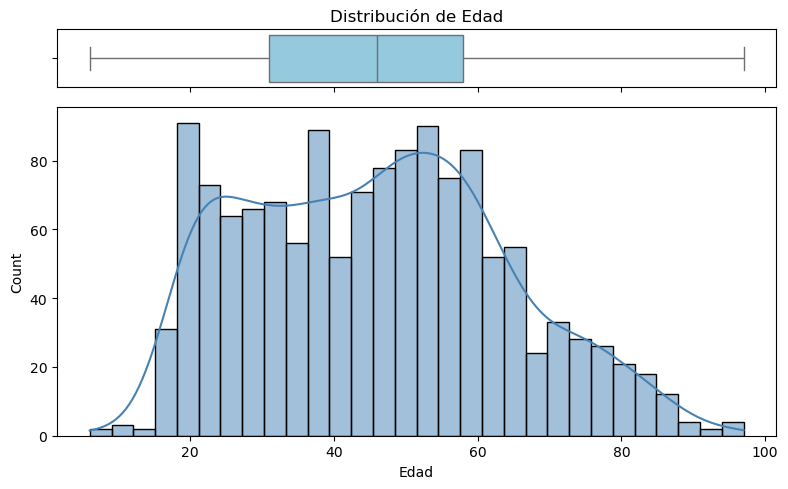

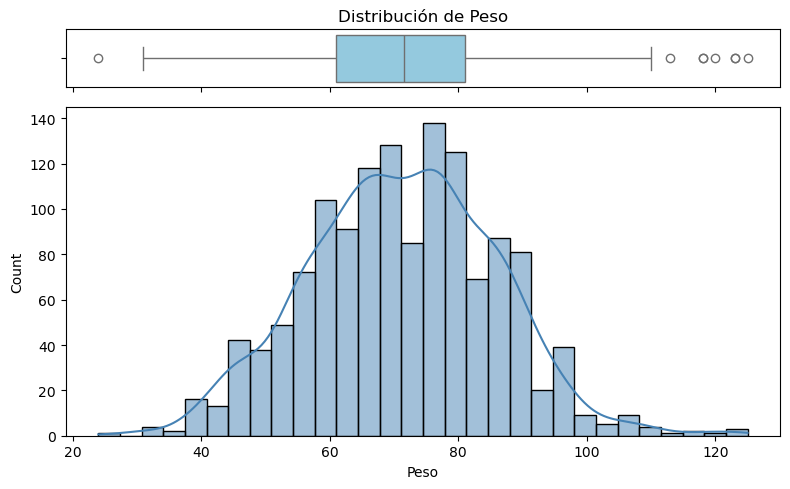

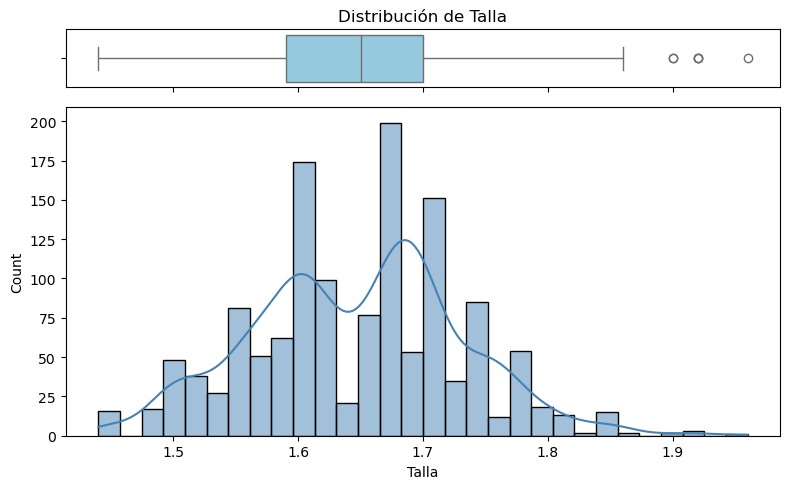

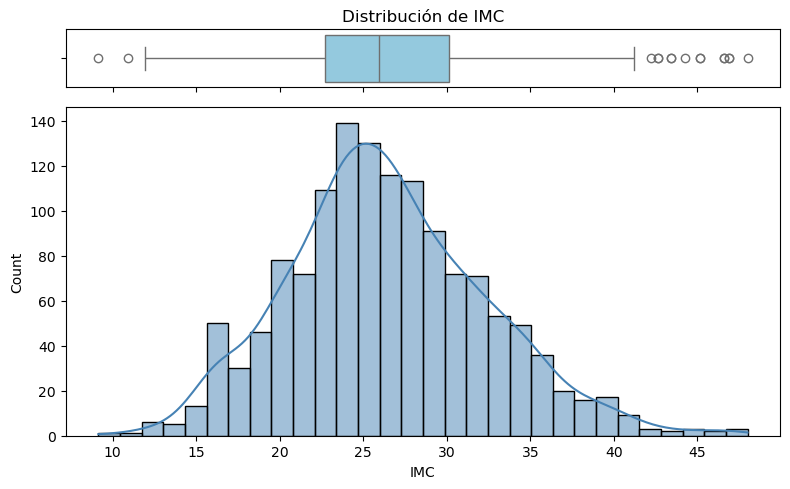

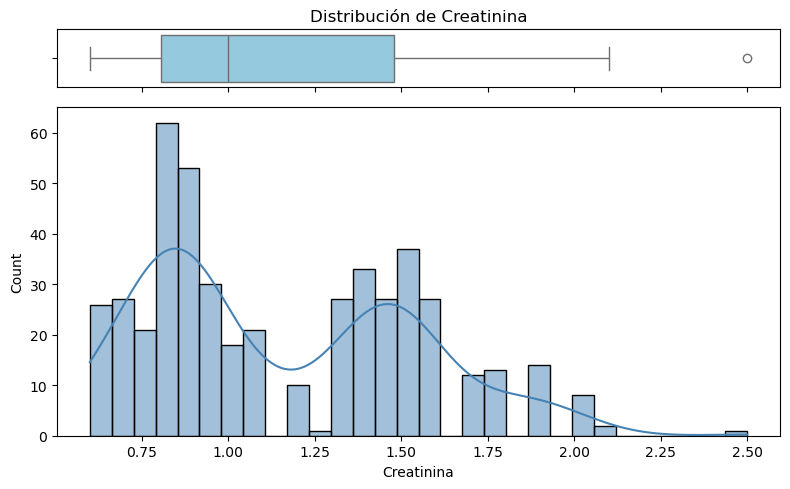

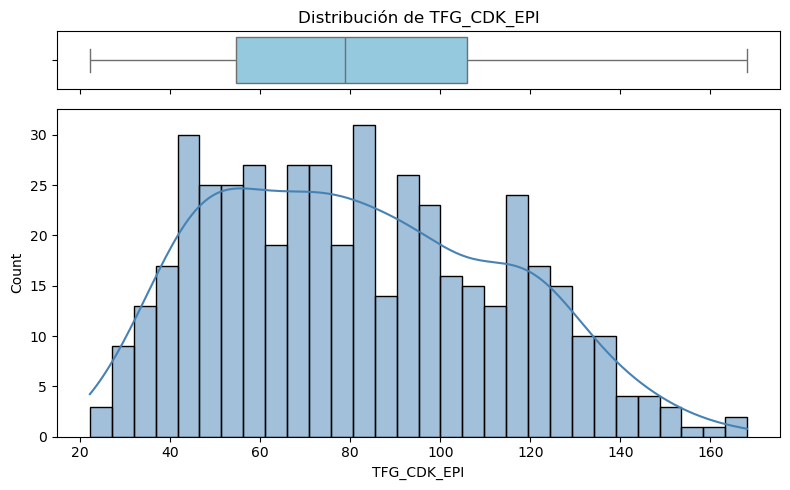

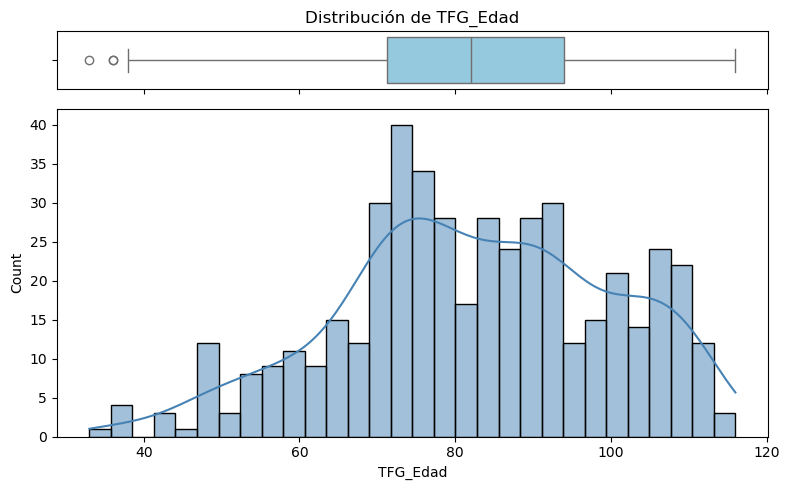

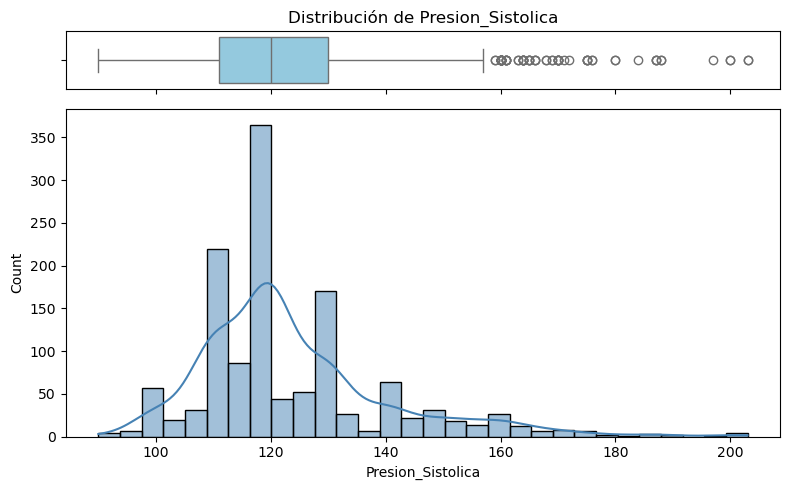

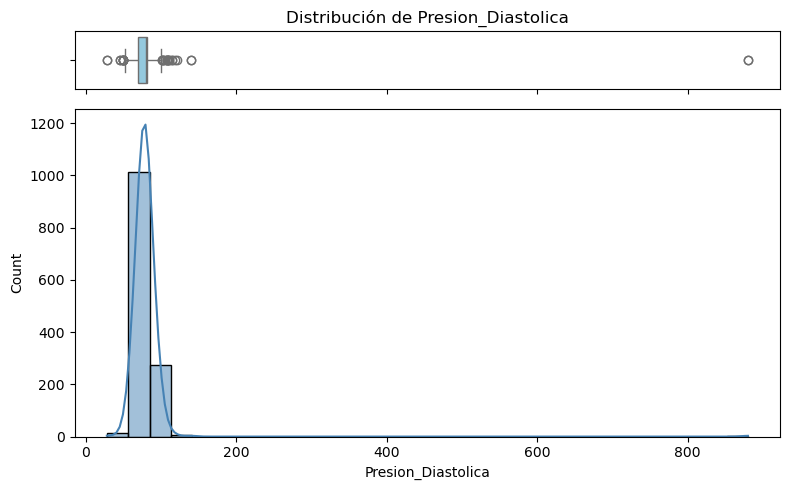

In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analisis_completo_numerico(df):
    # 1. Selección automática de variables numéricas
    df_num = df.select_dtypes(include=[np.number])
    
    # 2. Estadísticos descriptivos (Transpuestos para mejor lectura)
    print("--- RESUMEN ESTADÍSTICO ---")
    # Incluimos skewness (asimetría) para ver el sesgo clínico
    descriptivo = df_num.describe().T
    descriptivo['skewness'] = df_num.skew() 
    
    # Aplicamos un estilo limpio a la tabla descriptiva
    display(descriptivo.style.format("{:.2f}").set_caption("Estadísticas Descriptivas de Variables Clínicas"))
    
    # 3. Visualización de Distribuciones
    print("\n--- VISUALIZACIÓN DE DISTRIBUCIONES ---")
    for col in df_num.columns:
        # Ignoramos columnas que solo tengan nulos
        if df_num[col].dropna().empty:
            continue
            
        fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                              gridspec_kw={"height_ratios": (.15, .85)},
                                              figsize=(8, 5))
        
        # Boxplot para detectar Outliers 
        sns.boxplot(x=df_num[col], ax=ax_box, color="skyblue")
        ax_box.set(xlabel='', title=f'Distribución de {col}')
        
        # Histograma con KDE para ver la "forma" de la población
        sns.histplot(df_num[col], ax=ax_hist, kde=True, color="steelblue", bins=30)
        
        plt.tight_layout()
        plt.show()


analisis_completo_numerico(df)

In [330]:
from scipy import stats
import pandas as pd

def prueba_normalidad(df):
    # Seleccionamos solo las numéricas y quitamos nulos para la prueba
    df_num = df.select_dtypes(include=[np.number])
    resultados = []

    for col in df_num.columns:
        datos = df_num[col].dropna()
        
        if len(datos) > 3:
            stat, p_valor = stats.shapiro(datos)
            distribucion = "Sigue una distribución Normal" if p_valor > 0.05 else "No sigue una dirstribución Normal"
            
            resultados.append({
                'Variable': col,
                'Estadístico': f"{stat:.4f}",
                'p-valor': f"{p_valor:.4e}", 
                'Resultado': distribucion
            })

    df_res = pd.DataFrame(resultados)
    return df_res


tabla_normalidad = prueba_normalidad(df)
display(tabla_normalidad)

,Variable,Estadístico,p-valor,Resultado
0,Edad,0.9768,5.8147e-14,No sigue una dirstribución Normal
1,Peso,0.9959,9.6990e-04,No sigue una dirstribución Normal
2,Talla,0.9900,5.5726e-08,No sigue una dirstribución Normal
3,IMC,0.9908,1.6764e-07,No sigue una dirstribución Normal
4,Creatinina,0.9323,9.2905e-14,No sigue una dirstribución Normal
5,TFG_CDK_EPI,0.9736,1.6603e-07,No sigue una dirstribución Normal
6,TFG_Edad,0.9817,1.1942e-05,No sigue una dirstribución Normal
7,Presion_Sistolica,0.8895,1.3237e-29,No sigue una dirstribución Normal
8,Presion_Diastolica,0.1839,1.2414e-59,No sigue una dirstribución Normal


In [331]:
variables_enfoque = ['Regimen_Salud', 'Creatinina_Alta', 'Medico_Cabecera']
var_socdem = ['Departamento_Tamizaje', 'Municipio_Tamizaje', 'Edad', 'Genero', 'Escolaridad', 'Regimen_Salud']

In [332]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def graficar_frecuencias_y_porcentajes(df, vector_columnas):
    """
    Toma un dataframe y un vector de nombres de columnas para graficar
    barras con conteo y porcentaje sobre cada barra.
    """
    for col in vector_columnas:
        plt.figure(figsize=(10, 6))
        
        # 1. Calcular frecuencias
        ax = sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)
        
        # 2. Configuración de títulos
        plt.title(f'Distribución de {col}', fontsize=15)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Frecuencia Absoluta', fontsize=12)
        plt.xticks(rotation=45) # Rotación por si los nombres son largos
        
        # 3. Calcular y anotar Porcentajes y Cantidades
        total = len(df[col].dropna())
        for p in ax.patches:
            # Calcular porcentaje
            percentage = '{:.1f}%'.format(100 * p.get_height() / total)
            # Valor absoluto
            count = int(p.get_height())
            
            # Ubicación del texto (x, y)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            
            # Anotación (Cantidad \n Porcentaje)
            ax.annotate(f'{count}\n({percentage})', (x, y), 
                        ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color='black')

        plt.tight_layout()
        plt.show()

# --- MODO DE USO ---
# vars_socio = ['Genero', 'Escolaridad', 'Regimen_Salud']
# graficar_frecuencias_y_porcentajes(df, vars_socio)

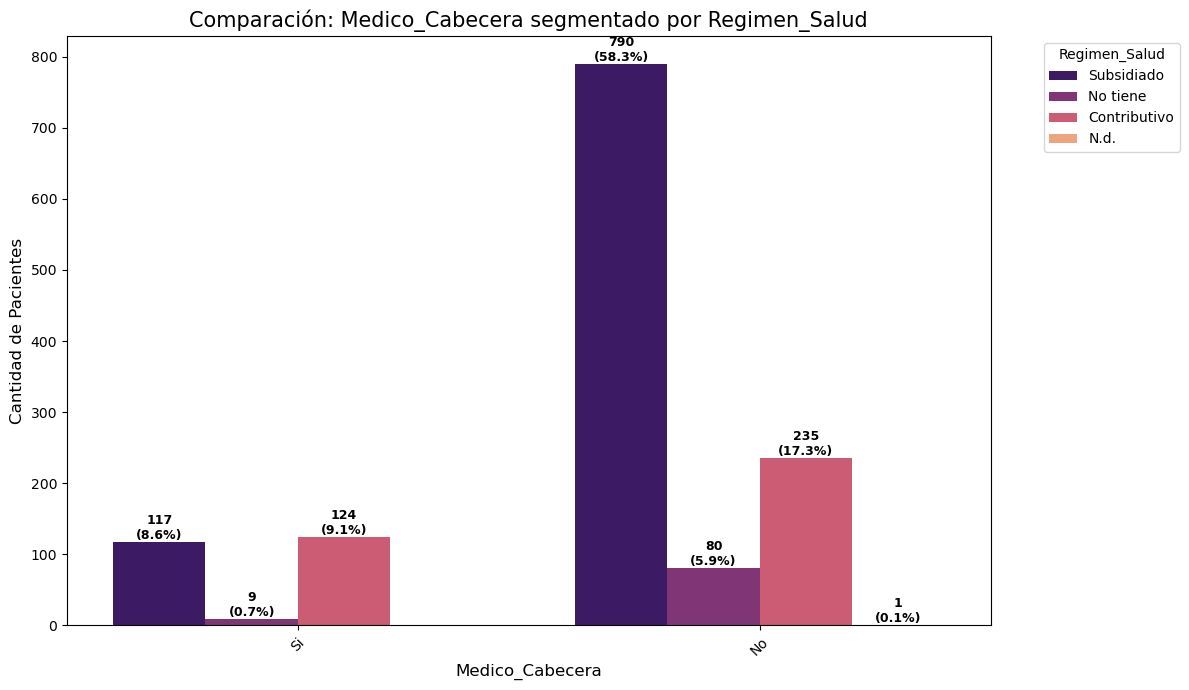

In [333]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def graficar_comparacion_categorica(df, var_principal, var_segmento):
    """
    Grafica la relación entre dos variables categóricas.
    var_principal: La variable que irá en el eje X (ej. Municipio)
    var_segmento: La variable que dividirá las barras por color (ej. Genero)
    """
    plt.figure(figsize=(12, 7))
    
    # 1. Crear el gráfico de conteo agrupado
    ax = sns.countplot(x=var_principal, hue=var_segmento, data=df, palette='magma')
    
    # 2. Configuración estética
    plt.title(f'Comparación: {var_principal} segmentado por {var_segmento}', fontsize=15)
    plt.xlabel(var_principal, fontsize=12)
    plt.ylabel('Cantidad de Pacientes', fontsize=12)
    plt.legend(title=var_segmento, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

    # 3. Añadir etiquetas de cantidad y porcentaje
    # Calculamos el total de datos no nulos para porcentajes globales
    total = len(df[var_principal].dropna())
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Solo anotar si hay datos
            percentage = '{:.1f}%'.format(100 * height / total)
            ax.annotate(f'{int(height)}\n({percentage})', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

graficar_comparacion_categorica(df, 'Medico_Cabecera', 'Regimen_Salud')

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

def prueba_chi_cuadrado_proporcional(df, var1, var2):
    """
    Realiza Chi-cuadrado y muestra la tabla de contingencia 
    con porcentajes calculados por fila (proporciones).
    """
    # 1. Tabla de frecuencias absolutas (para el cálculo de Chi2)
    tabla_abs = pd.crosstab(df[var1], df[var2])
    
    # 2. Tabla de porcentajes por fila (Normalizada por el índice)
    # Multiplicamos por 100 y redondeamos para que sea legible
    tabla_pct = pd.crosstab(df[var1], df[var2], normalize='index') * 100
    
    # 3. Ejecutar la prueba estadística
    chi2, p, dof, expected = chi2_contingency(tabla_abs)
    
    print(f"=== PRUEBA CHI-CUADRADO: {var1} vs {var2} ===")
    print(f"Estadístico Chi2: {chi2:.4f}")
    print(f"p-valor: {p:.4e}")
    print("-" * 45)
    
    if p < 0.05:
        print("✅ RELACIÓN SIGNIFICATIVA: El acceso a Médico de Cabecera depende del Régimen.")
    else:
        print("❌ INDEPENDIENTES: No hay evidencia de que el Régimen afecte el acceso.")
    
    print("\n--- Tabla de Porcentajes por Fila (%) ---")
    # Formateamos para mostrar solo un decimal y el símbolo %
    display(tabla_pct.round(1).astype(str) + '%')
    
    return p

# Ejecución
p_val = prueba_chi_cuadrado_proporcional(df, 'Regimen_Salud', 'Medico_Cabecera')

In [346]:
import pandas as pd
from scipy.stats import chi2_contingency

def prueba_chi_cuadrado(df, var1, var2):
    """
    Realiza la prueba de Chi-cuadrado de independencia entre dos variables.
    Muestra la tabla de frecuencias y los resultados estadísticos.
    """
    # 1. Crear la tabla de contingencia (frecuencias observadas)
    # Eliminamos nulos para que la prueba sea válida
    tabla_contingencia = pd.crosstab(df[var1], df[var2])
    
    # 2. Ejecutar la prueba
    # chi2: Estadístico, p: p-valor, dof: grados de libertad, expected: frec. esperadas
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    
    print(f"=== PRUEBA CHI-CUADRADO: {var1} vs {var2} ===")
    print(f"Estadístico Chi2: {chi2:.4f}")
    print(f"p-valor: {p:.4e}")
    print(f"Grados de libertad: {dof}")
    print("-" * 40)
    
    # 3. Interpretación del p-valor
    if p < 0.05:
        print("Existe una RELACIÓN significativa entre las variables (p < 0.05).")
    else:
        print("NO hay evidencia de relación. Las variables son independientes.")
    
    print("\n--- Tabla de Frecuencias Observadas ---")
    display(tabla_contingencia)
    
    return p

p_val = prueba_chi_cuadrado(df, 'Medico_Cabecera', 'Regimen_Salud')

=== PRUEBA CHI-CUADRADO: Medico_Cabecera vs Regimen_Salud ===
Estadístico Chi2: 84.6633
p-valor: 4.1266e-19
Grados de libertad: 2
----------------------------------------
Existe una RELACIÓN significativa entre las variables (p < 0.05).

--- Tabla de Frecuencias Observadas ---


Regimen_Salud,Contributivo,No tiene,Subsidiado
Medico_Cabecera,,,
No,235,81,790
Si,124,9,117


In [335]:
mapeo = {
    'Subsidiado': 'Subsidiado', 
    'No tiene': 'No tiene',
    'Contributivo': 'Contributivo',
    'N.d.': 'No tiene'
}

df['Regimen_Salud'] = df['Regimen_Salud'].replace(mapeo)

print(df['Regimen_Salud'].value_counts())

Regimen_Salud
Subsidiado      907
Contributivo    359
No tiene         90
Name: count, dtype: int64


In [336]:
p_val = prueba_chi_cuadrado(df, 'Medico_Cabecera', 'Regimen_Salud')

=== PRUEBA CHI-CUADRADO: Medico_Cabecera vs Regimen_Salud ===
Estadístico Chi2: 84.6633
p-valor: 4.1266e-19
Grados de libertad: 2
----------------------------------------
Existe una RELACIÓN significativa entre las variables (p < 0.05).

--- Tabla de Frecuencias Observadas ---


Regimen_Salud,Contributivo,No tiene,Subsidiado
Medico_Cabecera,,,
No,235,81,790
Si,124,9,117


In [337]:
p_val = prueba_chi_cuadrado(df, 'Medico_Cabecera', 'Ultima_Consulta_Medica')

=== PRUEBA CHI-CUADRADO: Medico_Cabecera vs Ultima_Consulta_Medica ===
Estadístico Chi2: 88.9501
p-valor: 5.0056e-17
Grados de libertad: 6
----------------------------------------
Existe una RELACIÓN significativa entre las variables (p < 0.05).

--- Tabla de Frecuencias Observadas ---


Ultima_Consulta_Medica,Hace un mes,Hace una semana,Mayor a 1 año,Mayor a 2 años,Mayor a 3 meses,Mayor a 6 meses,Mayor a un mes
Medico_Cabecera,,,,,,,
No,153,108,254,257,120,77,137
Si,70,32,16,26,27,20,59


In [347]:
p_val = prueba_chi_cuadrado(df, 'Regimen_Salud', 'Dificultad_Atencion_Medica')

=== PRUEBA CHI-CUADRADO: Regimen_Salud vs Dificultad_Atencion_Medica ===
Estadístico Chi2: 50.7790
p-valor: 3.2805e-09
Grados de libertad: 6
----------------------------------------
Existe una RELACIÓN significativa entre las variables (p < 0.05).

--- Tabla de Frecuencias Observadas ---


Dificultad_Atencion_Medica,Difícil,Facil,Muy Dificil,Muy Facil
Regimen_Salud,,,,
Contributivo,106,197,12,44
No tiene,18,53,16,3
Subsidiado,298,489,78,42


In [348]:
pd.crosstab(
    df["Regimen_Salud"],
    df["Dificultad_Atencion_Medica"],
    rownames=["Regimen_Salud"],
    colnames=["Dificultad_Atencion_Medica"], normalize = "index"
)

Dificultad_Atencion_Medica,Difícil,Facil,Muy Dificil,Muy Facil
Regimen_Salud,,,,
Contributivo,0.295265,0.548747,0.033426,0.122563
No tiene,0.200000,0.588889,0.177778,0.033333
Subsidiado,0.328556,0.539140,0.085998,0.046307


In [ ]:
p_val = prueba_chi_cuadrado(df, 'Medico_Cabecera', 'Dificultad_Atencion_Medica')


=== PRUEBA CHI-CUADRADO: Medico_Cabecera vs Dificultad_Atencion_Medica ===
Estadístico Chi2: 46.9177
p-valor: 3.6185e-10
Grados de libertad: 3
----------------------------------------
Existe una RELACIÓN significativa entre las variables (p < 0.05).

--- Tabla de Frecuencias Observadas ---


Dificultad_Atencion_Medica,Difícil,Facil,Muy Dificil,Muy Facil
Medico_Cabecera,,,,
No,363,582,104,57
Si,59,157,2,32


In [339]:
p_val = prueba_chi_cuadrado(df, 'Medico_Cabecera', 'Ultimo_Profesional_Salud')

=== PRUEBA CHI-CUADRADO: Medico_Cabecera vs Ultimo_Profesional_Salud ===
Estadístico Chi2: 74.9697
p-valor: 9.4395e-15
Grados de libertad: 5
----------------------------------------
Existe una RELACIÓN significativa entre las variables (p < 0.05).

--- Tabla de Frecuencias Observadas ---


Ultimo_Profesional_Salud,Cardiologo,Endocrinologo,Enfermera,Internista,Medico General,Nefrólogo
Medico_Cabecera,,,,,,
No,4,3,2,127,958,12
Si,2,0,0,42,180,26
